In [ ]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy
import requests
import io

from template_funciones import *
from template_funciones_2 import *


# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [ ]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('datos-museos/export.geojson')
barrios = gpd.read_file('datos-museos/barrios.geojson')

## Visualización

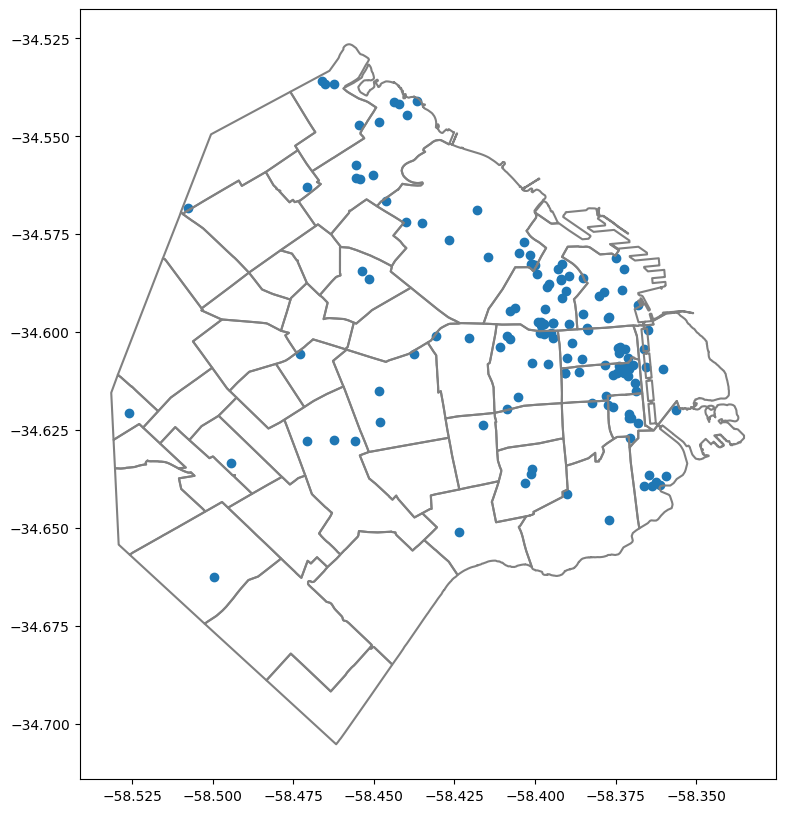

In [ ]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)
plt.show()

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184.

In [ ]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa),
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [ ]:
def construye_adyacencia(D,m):
    # Función que construye la matriz de adyacencia del grafo de museos
    # D matriz de distancias, m cantidad de links por nodo
    # Retorna la matriz de adyacencia como un numpy.
    D = D.copy()
    l = [] # Lista para guardar las filas
    for fila in D: # recorriendo las filas, anexamos vectores lógicos
        l.append(fila<=fila[np.argsort(fila)[m]] ) # En realidad, elegimos todos los nodos que estén a una distancia menor o igual a la del m-esimo más cercano
    A = np.asarray(l).astype(int) # Convertimos a entero
    np.fill_diagonal(A,0) # Borramos diagonal para eliminar autolinks
    return(A)

m = 3 # Cantidad de links por nodo
A = construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [ ]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

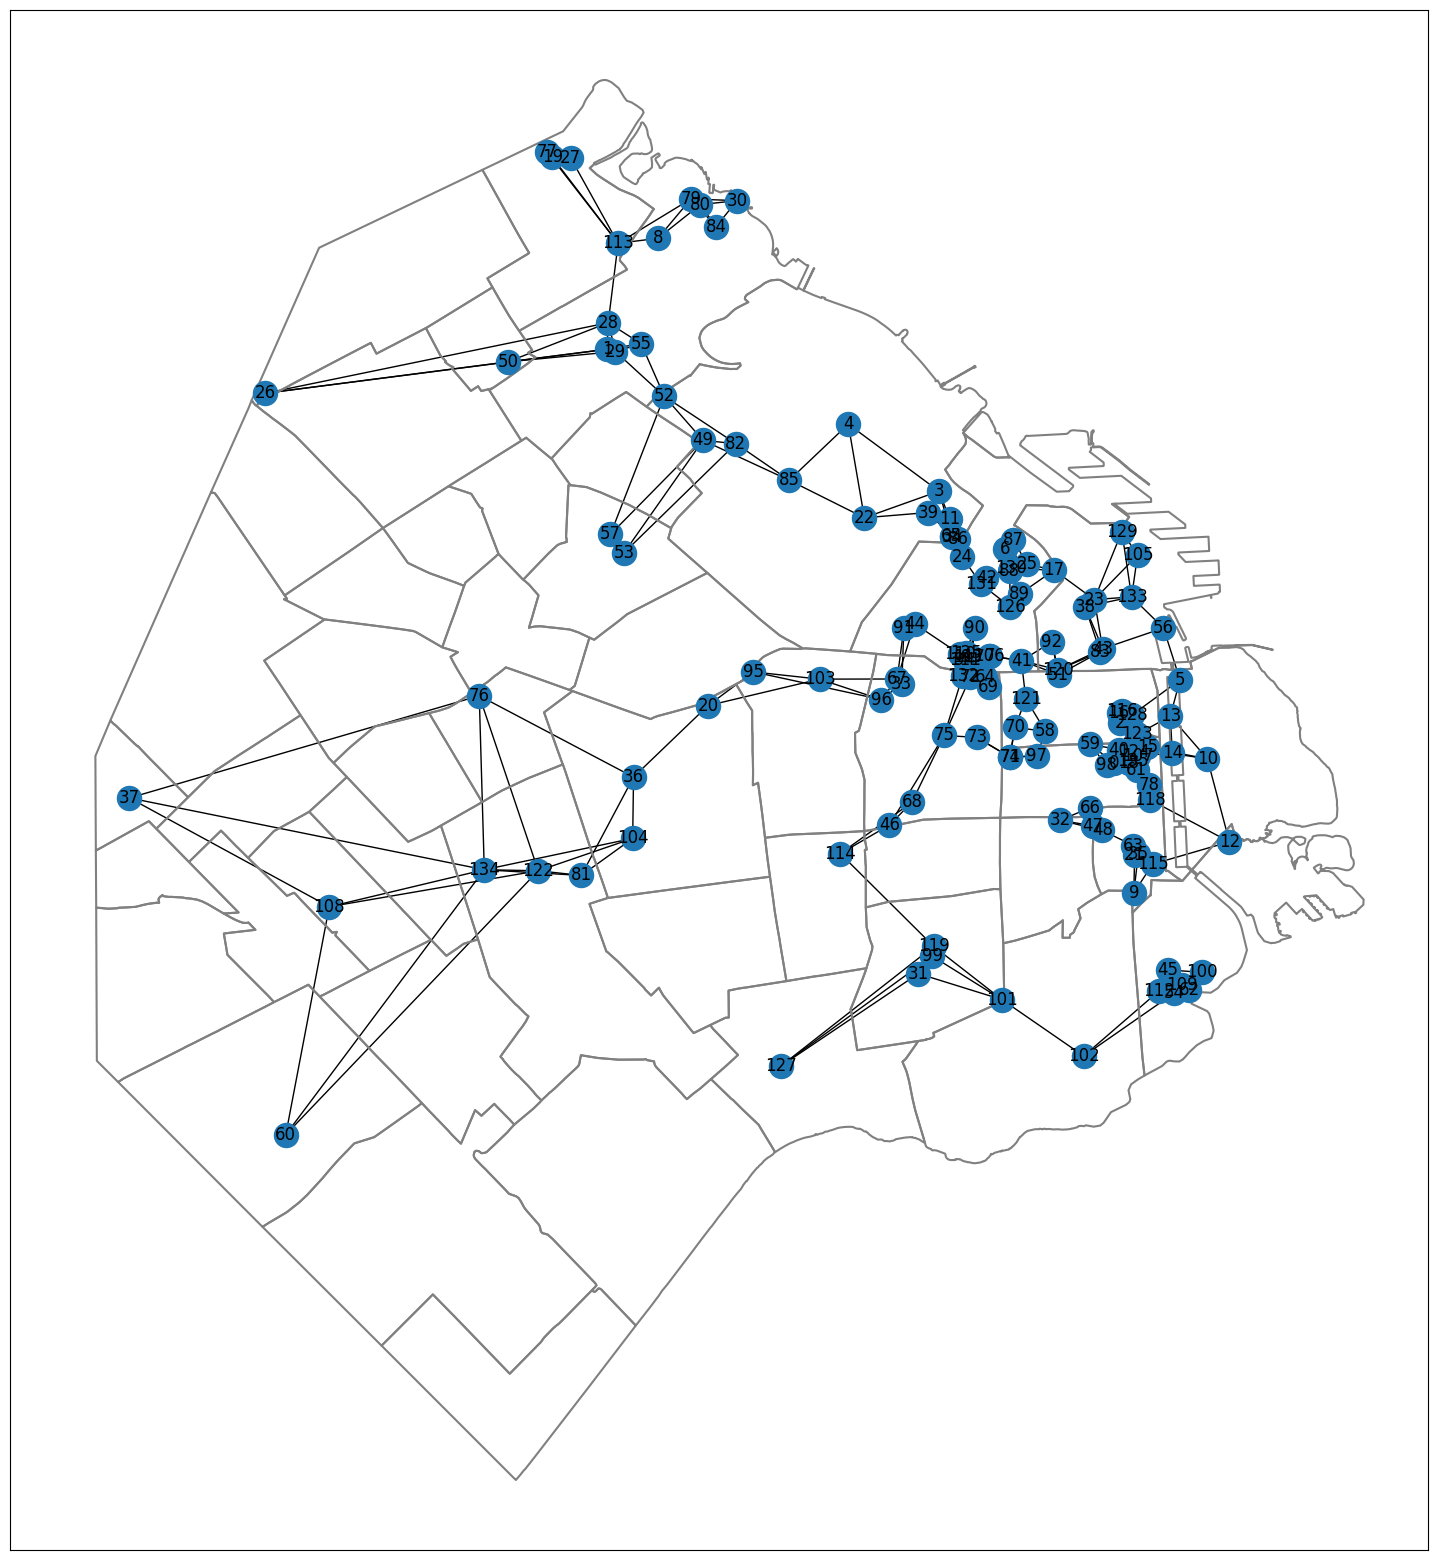

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Resolución del TP 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy
import requests
import io
import json

from template_funciones import *

museos = gpd.read_file('datos-museos/export.geojson')
barrios = gpd.read_file('datos-museos/barrios.geojson')

#museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
#barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Punto 1:

Partimos de la siguiente ecuación:  
  
**I) p = (1 - $\alpha$)Cp + $\frac{\alpha}{N}$1**  

Queremos demostrar que esta expresión es equivalente a $\frac{N}{\alpha}$(I - (1 - $\alpha$)C)p = 1  



I) $\Leftrightarrow$ p - (1 - $\alpha$)Cp = $\frac{\alpha}{N}$1  

$\Leftrightarrow$ (I - (1 - $\alpha$)C)p = $\frac{\alpha}{N}$1  

$\Leftrightarrow$ $\frac{N}{\alpha}$(I - (1 - $\alpha$)C)p = 1  

$\Leftrightarrow$ Mp = 1, con M = $\frac{N}{\alpha}$(I - (1 - $\alpha$)C)  

Queda asi demostrado lo que se quería ver.


## Punto 2:


**Demostración:**

Para que el sistema $M p = b$ tenga una única solución, alcanza con probar que $Nu(M)$ = $\{0\}$, es decir:

Si $X \in$ $Nu(M)$, entonces $X$ = $\vec{0}$

Procedemos por absurdo. Supongamos que existe un vector $X \neq 0$ tal que $M X = 0$.

Recordando que:
$$
M = \frac{N}{\alpha} (I - (1 - \alpha) C)
$$

y dado que $\frac{N}{\alpha} > 0$, podemos cancelarlo multiplicando a ambos lados por el inverso:
$$
(I - (1 - \alpha) C) X = 0
\Rightarrow X = (1 - \alpha) C X
$$

Tomamos norma 1 en ambos lados:
$$
\|X\|_1 = (1 - \alpha) \|C X\|_1
$$

Como $C$ es estocástica por columnas, se cumple ||C||$_1$ = 1, luego:
$$
\|C X\|_1 \leq \|X\|_1
$$

Por lo tanto:
$$
\|X\|_1 \leq (1 - \alpha) \|X\|_1
$$

Pero como $0 < 1 - \alpha < 1$, $\|X\|_1 = 0 \Rightarrow X = 0$, contradiciendo nuestra suposición.

**Conclusión:** $Nu(M) = \{0\}$, por lo tanto $M$ es invertible y el sistema $M p = b$ tiene una única solución.

## Punto 3:

### 3a

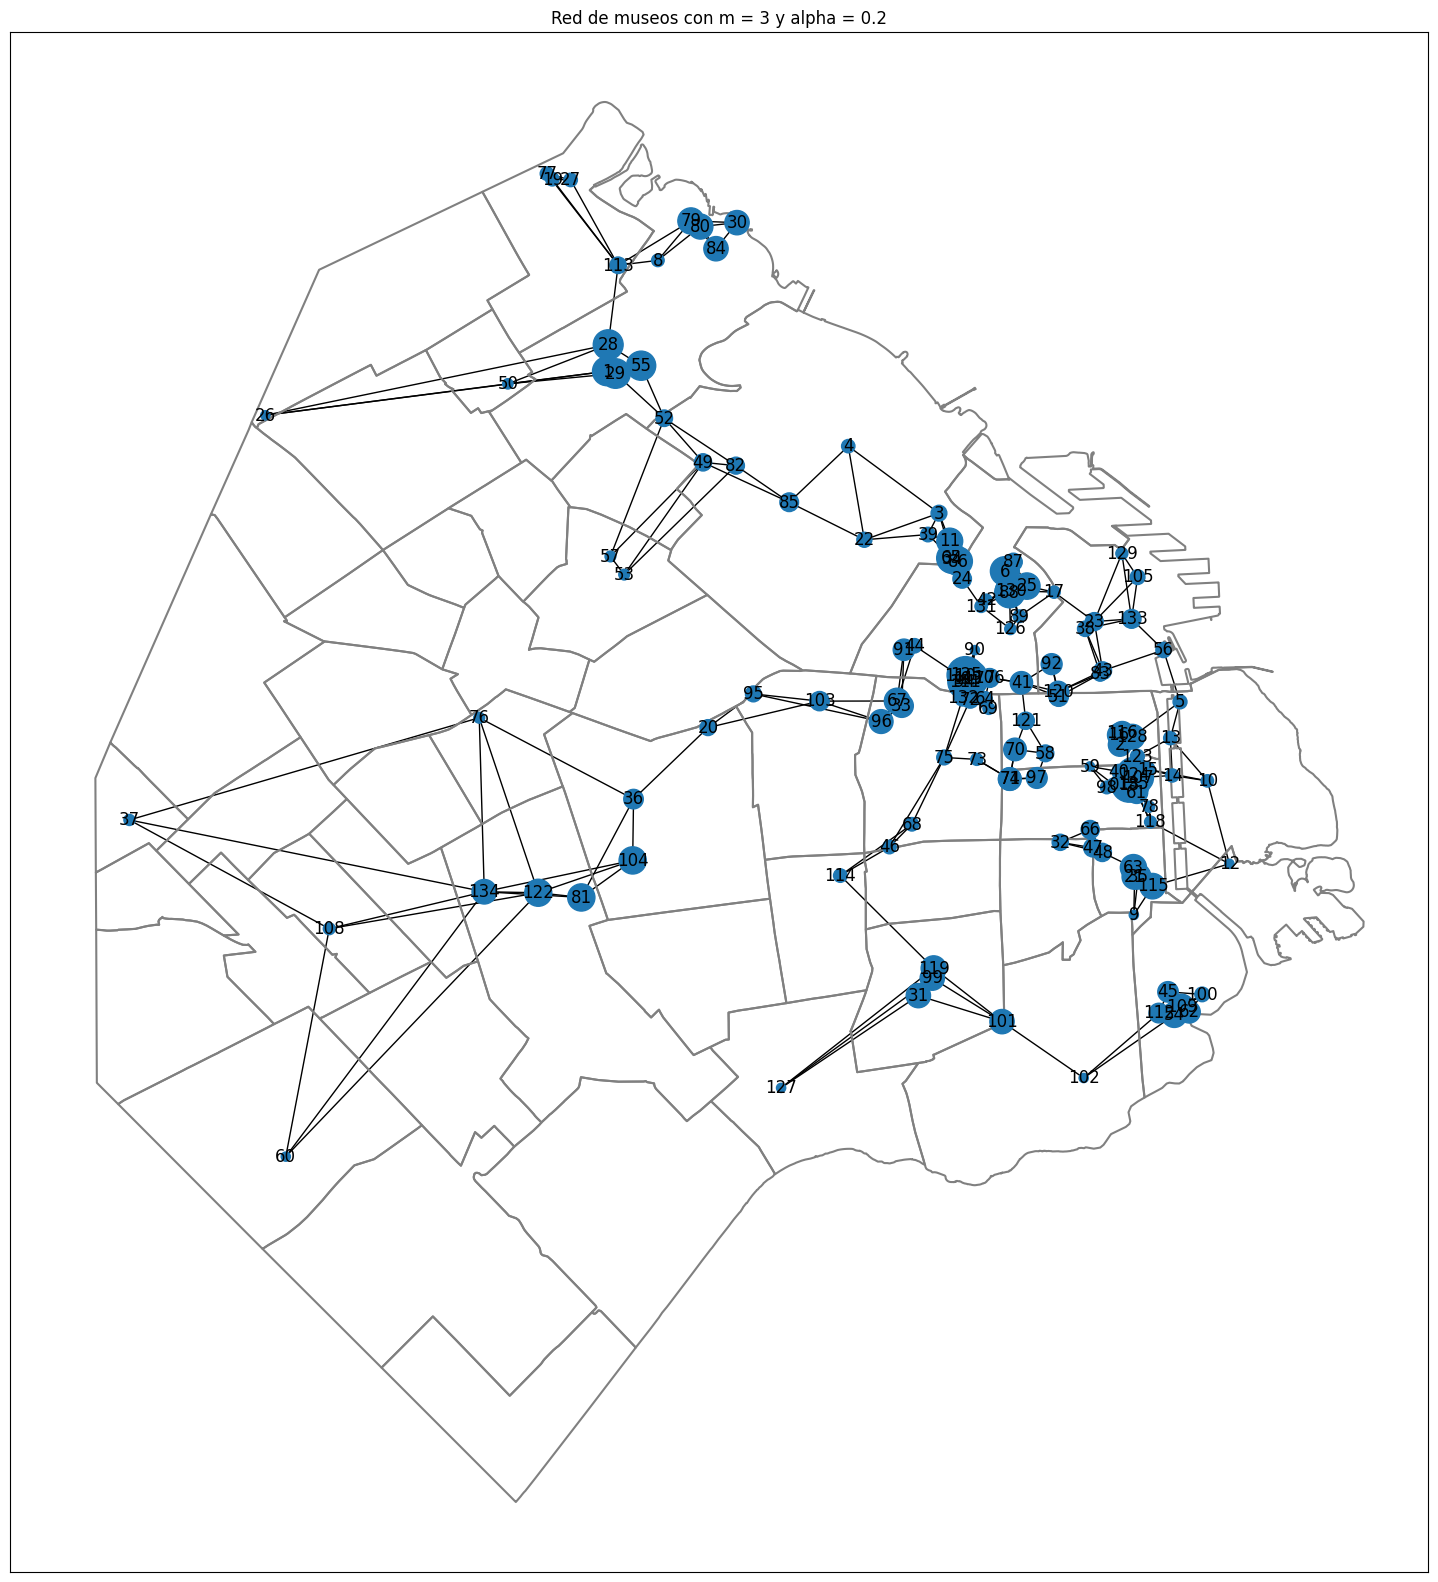

In [ ]:
D = construir_matriz_de_distancias(museos)

m = 3 # Cantidad de links por nodo
A = construye_adyacencia(D,m)
alpha = 1/5

p = calcula_pagerank(A, alpha)

graficar_red(A, museos, barrios, p, network_size=[20, 20], scale=30000, title=f"Red de museos con m = {m} y alpha = {alpha}")

### 3 - b, c

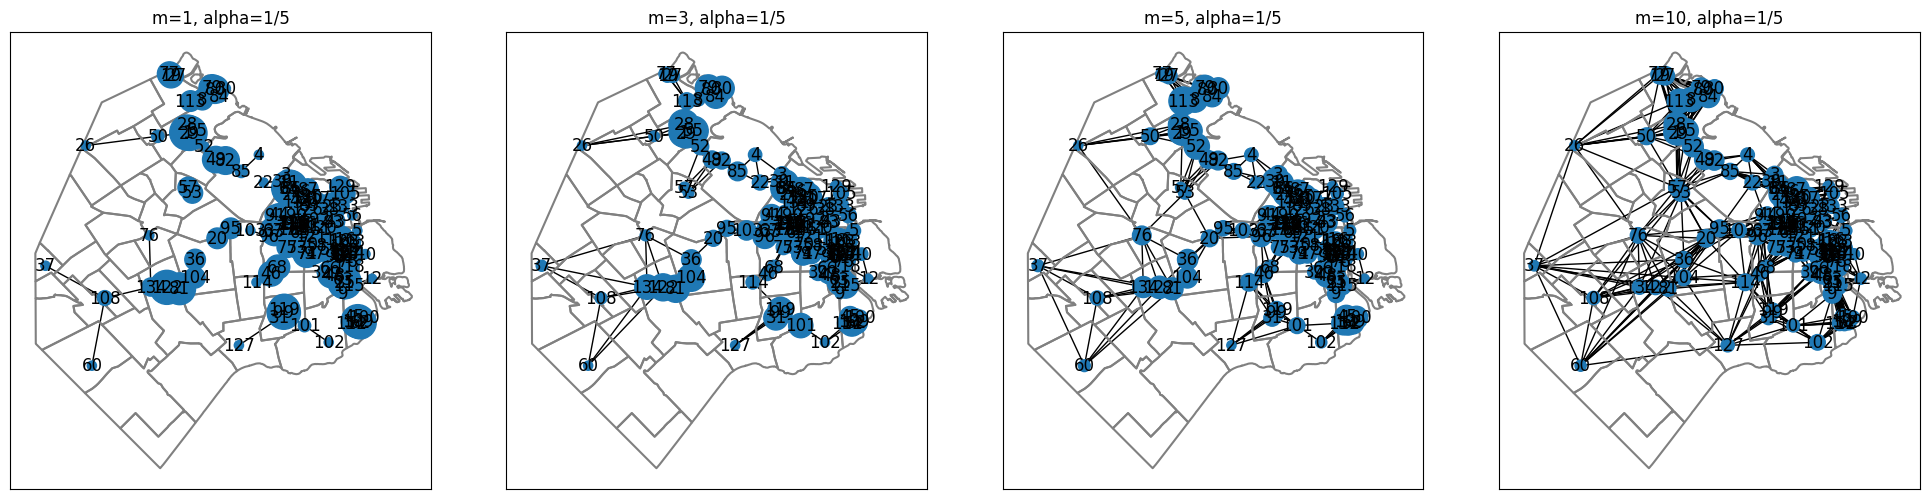

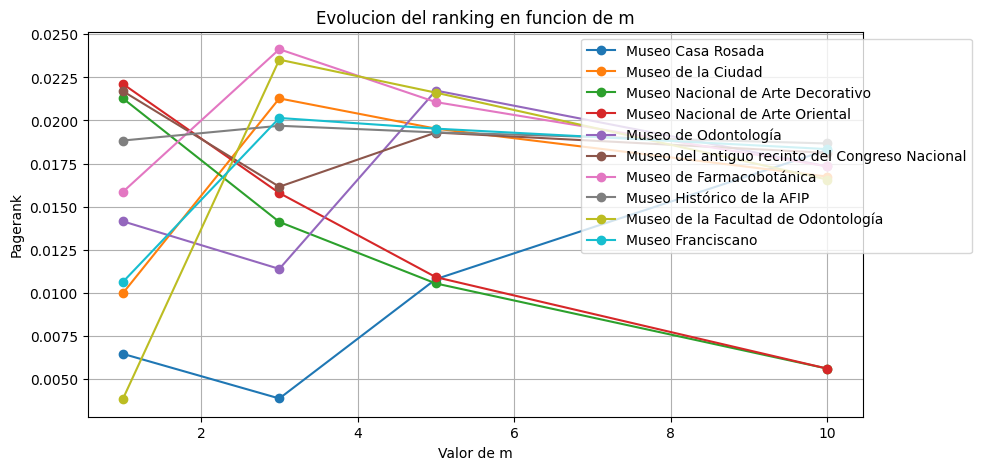

In [ ]:
top_ranking_por_m = {}
top_ranking_por_alpha = {}

#top_museos tendra todos los museos que estan el top 3 de los mas relevantes para algun valor de m y alpha.
top_museos = set()
page_ranks = []

valores_de_m = [1,3,5,10]
valores_de_alpha = [1/7, 1/5, 1/3, 1/2, 2/3, 4/5, 6/7]

with open("datos-museos/export.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

#Arreglo con los nombres de todos los museos donde el nombre en la posicion i, coincide con el nombre del museo i en el arreglo de museos
nombres = [f["properties"]["name"] for f in data["features"]]

fig1, axs1 = plt.subplots(1, len(valores_de_m), figsize=(20,5))  # Subplots horizontal
page_ranks = []
page_ranks_m = []
page_ranking_m= []
top_museos_m = []
top_museos = set()
# Imprimimos los diferentes graficos con las redes del top 3 de museos para alpha = 1/5 y cada variacion de m.
for idx, m in enumerate(valores_de_m):
    A = construye_adyacencia(D, m)
    p = calcula_pagerank(A, 1/5)
    page_ranks.append(p)
    page_ranks_m.append(p)
    page_ranking_m.append(1 + np.argsort(np.argsort(p)[::-1]))

    #Ordenamos los pageranks quedandonos con los indices de los tres con puntaje mas alto, en orden decreciente.
    top_for_current_m = np.argsort(p)[-3:][::-1]

    #Guardamos los nombres de los tres museos con puntaje mas alto.
    top_ranking_por_m[m] = list(map(lambda idx: nombres[idx] + f' (p = {p[idx]:.5f})', top_for_current_m))

    #Agregamos los tres museos al top de museos.
    top_museos = top_museos | set(top_for_current_m)
    graficar_red(A, museos, barrios, p, network_size=[5,5], scale=30000, title=f'm={m}, alpha=1/5', ax=axs1[idx])
top_museos_m = top_museos


plt.tight_layout()
plt.show()

# Representamos la evolucion de los distintos museos en el top del ranking en funcion de m.
construir_grafico_page_rank(
    x_values=valores_de_m,
    page_ranks=page_ranks,
    x_label="Valor de m",
    title="Evolucion del ranking en funcion de m",
    graph_size=[10,5],
    nombres_museos=nombres,
    top_museos=sorted(top_museos))

### Comportamiento con respecto a $m$:

Con valores bajos de $m$, los **museos de arte** tienen mayor relevancia. Sin embargo, al aumentar $m$ a un valor superior a 1, estos museos desaparecen del ranking.

Para valores intermedios de $m$, los museos de **odontología** y **farmacobotánica** dominan las primeras posiciones. Sin embargo, cuando $m$ alcanza un valor de 10, desaparecen de las primeras posiciones.

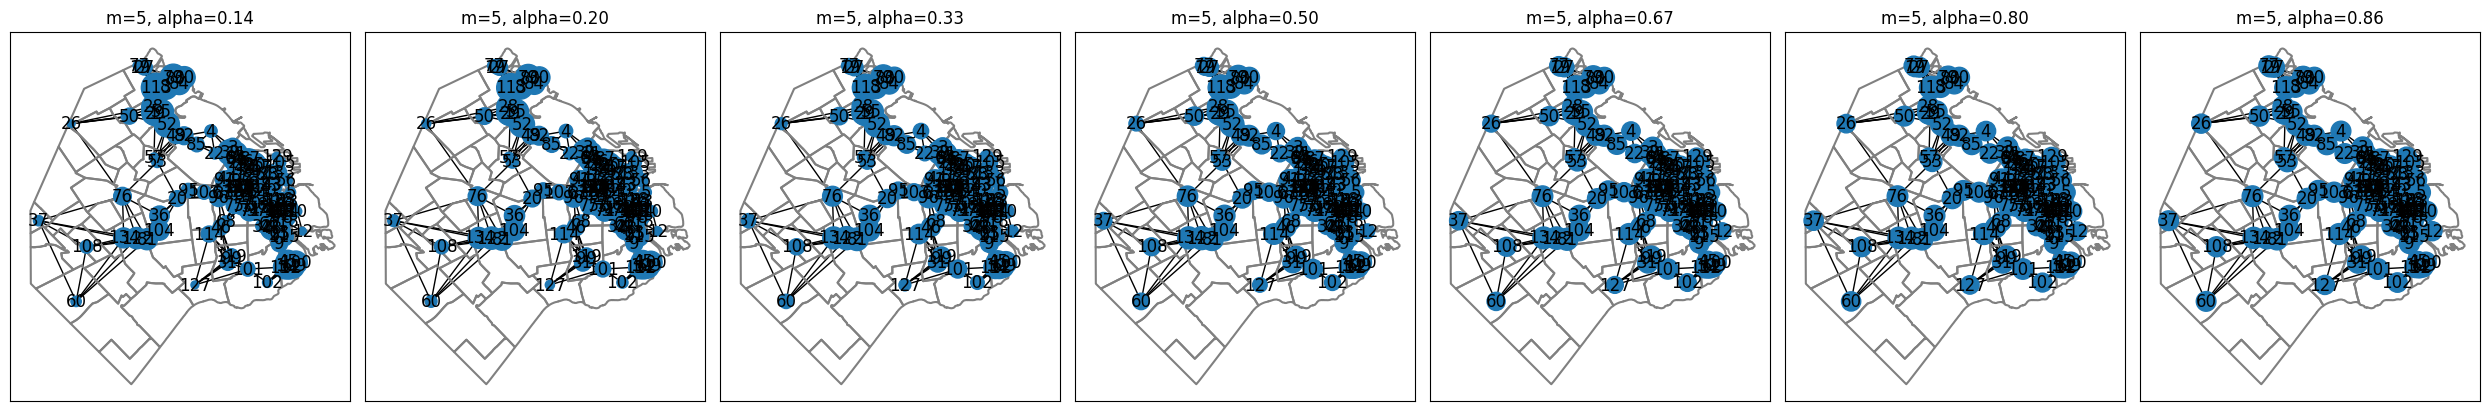

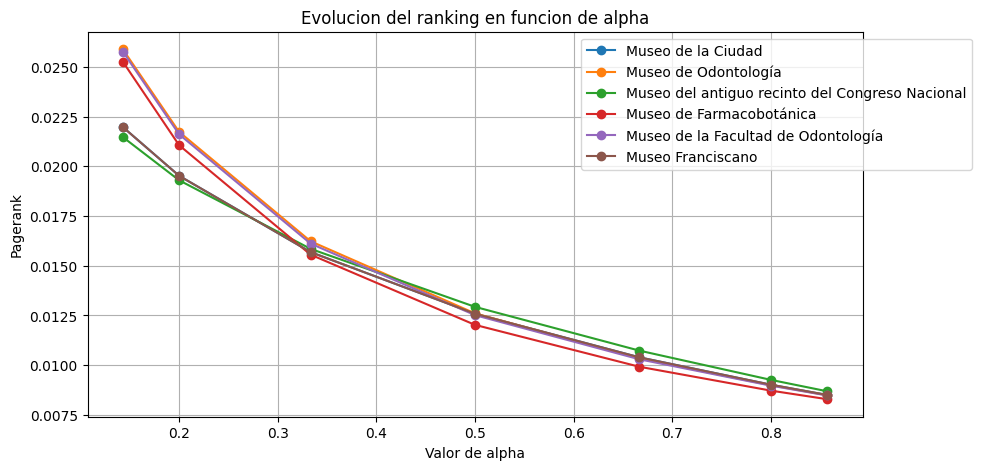

In [ ]:
# Mostramos los distintos gráficos de las redes del top 3 de museos para m = 5 y cada valor de alpha.
# La lógica es la misma que cuando m era la variable cambiante. Idealmente esto debería estar encapsulado en una función, pero no hubo presupuesto.
A = construye_adyacencia(D, 5)
fig2, axs2 = plt.subplots(1, len(valores_de_alpha), figsize=(25,5))

page_ranks = []
page_ranks_alpha = []
top_museos = set()
page_ranking_alpha = []
top_museos_alpha = []

for idx, alpha in enumerate(valores_de_alpha):
    p = calcula_pagerank(A, alpha)
    page_ranks.append(p)
    page_ranks_alpha.append(p)
    page_ranking_alpha.append(1 + np.argsort(np.argsort(p)[::-1]))

    top_for_current_alpha = np.argsort(p)[-3:][::-1]
    top_ranking_por_alpha[alpha] = list(map(lambda idx: nombres[idx] + f' (p = {p[idx]:.5f})', top_for_current_alpha))
    top_museos = top_museos | set(top_for_current_alpha)
    graficar_red(A, museos, barrios, p, network_size=[5,5], scale=30000, title=f'm=5, alpha={alpha:.2f}', ax=axs2[idx])

top_museos_alpha = top_museos

plt.tight_layout()
plt.show()

# Representamos la evolucion de los distintos museos en el top del ranking en funcion de alpha.
construir_grafico_page_rank(
    x_values=valores_de_alpha,
    page_ranks=page_ranks,
    x_label="Valor de alpha",
    title="Evolucion del ranking en funcion de alpha",
    graph_size=[10,5],
    nombres_museos=nombres,
    top_museos=sorted(top_museos))

### Comportamiento con respecto a $\alpha$:

A diferencia de $m$, el comportamiento al modificar $\alpha$ no presenta cambios tan drásticos. Para valores de $\alpha \geq \frac{1}{2}$, los **museos del Antiguo Recinto del Congreso Nacional**, el **Museo Franciscano** y el **Museo de la Ciudad** dominan las primeras posiciones. No obstante, al reducir $\alpha$ por debajo de $\frac{1}{2}$, estos museos son completamente desplazados por los de **odontología** y **farmacobotánica**.

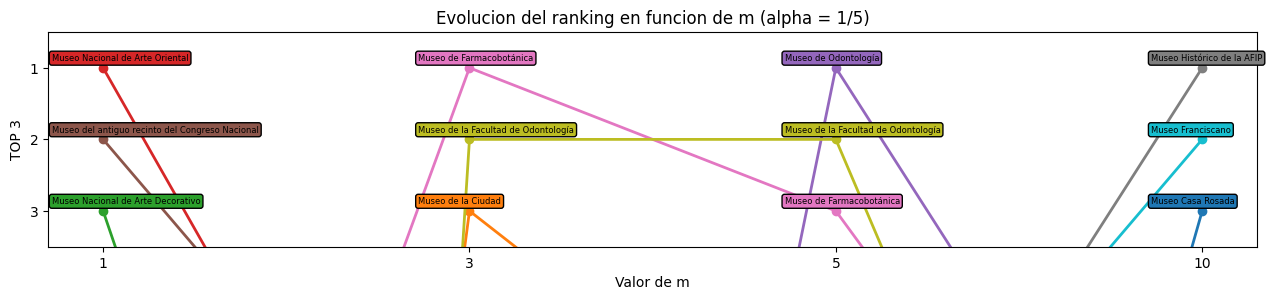

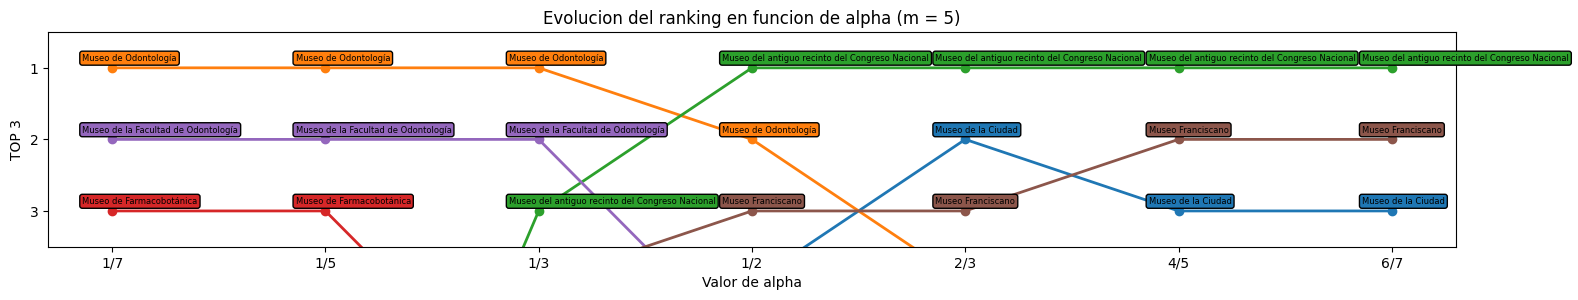

In [ ]:
# TABLAS RESUMEN:
# Construimos las tablas para representar la variacion de m y alpha entre el top de museos.
valores_de_alpha_letras = ['1/7', '1/5', '1/3', '1/2', '2/3', '4/5', '6/7']

# construir_tabla("Variacion del top al modificar m (alpha = 1/5)", [25,3], "Valor de m", top_ranking_por_m)
# construir_tabla("Variacion del top al modificar alpha (m = 5)", [25,5], "Valor de alpha", top_ranking_por_alpha)
construir_grafico_rankings(
    x_values=valores_de_m,
    y_values=page_ranking_m,
    pr_values=page_ranks_m,
    x_label="Valor de m",
    y_label="TOP 3",
    title="Evolucion del ranking en funcion de m (alpha = 1/5)",
    graph_size=[13,3],
    nombres_museos=nombres,
    top_museos=sorted(top_museos_m))

construir_grafico_rankings(
    x_values=valores_de_alpha_letras,
    y_values=page_ranking_alpha,
    pr_values=page_ranks_alpha,
    x_label="Valor de alpha",
    y_label="TOP 3",
    title="Evolucion del ranking en funcion de alpha (m = 5)",
    graph_size=[16,3],
    nombres_museos=nombres,
    top_museos=sorted(top_museos_alpha))

Las posiciones en el ranking no son estables, ya que experimentan cambios al modificar los parámetros $m$ y/o $\alpha$. Sin embargo, los ajustes en $m$ provocan variaciones mucho más bruscas que los cambios en $\alpha$.

Se observa claramente que, al aumentar el valor de $m$ o disminuir el de $\alpha$, los museos ubicados en zonas **céntricas** ganan relevancia de manera notable, en comparación con aquellos situados en zonas periféricas.

A continuación, desglosamos el análisis del comportamiento de las posiciones en el ranking al modificar $m$ y $\alpha$:

Es interesante notar que existen museos cuya relevancia está asociada a redes con **pocas conexiones**. Un claro ejemplo es el **Museo Nacional de Arte Oriental**, que solo ocupa las primeras posiciones

Por otro lado, hay museos cuya relevancia crece a medida que **aumenta el número de conexiones**. El **Museo Histórico de la AFIP**, por ejemplo, no apareció en las primeras posiciones hasta que *m* alcanzó el valor de 10.

## Punto 4:

Dado:

- $v \in R^N$, donde $v_i$ representa la cantidad de personas que comenzaron la visita en el museo $i$.
- $C \in R^{N \times N}$, la matriz de transición, donde $C_{ij}$ representa la probabilidad de moverse al museo j luego de haber visitado el $i$.
- $r$, el número total de visitas que cada persona realiza antes de abandonar la red.

De tal manera que siendo $v_0 \in R^N$ los museos que son la primer visita de los visitantes, luego de k pasos, la cantidad esperada de visitantes $v_k = C^k v_0$

Queremos demostrar que el vector $v$ de ingresos iniciales se puede calcular como:

$v = B^{-1} w, \quad \text{con} \quad B = \sum_{k = 0}^{r - 1} C^k.$

Si analizamos la evolución de las visitas, sabemos que:

- En el paso 0 (inicio), solo esperamos $v_0$ visitantes en el museo $i$.
- En el paso 1, $v_i$ = $C^1 v0$ visitantes en el museo $i$.
- En el paso 2, $v_i$ = $C^2 v0$ visitantes en el museo $i$.
$\ldots$
- En el paso $k$, esperamos ver $v_i$ = $C^k v0$ visitantes en el museo $i$.

Dado que cada persona realiza exactamente $r$ visitas antes de salir de la red, la cantidad total de visitas recibidas por cada museo es la suma de los visitantes esperados en todos los pasos:

$w = \sum_{k = 0}^{r - 1} C^k v$

Sabiendo que B se define como:

$B = \sum_{k = 0}^{r - 1} C^k$

podemos escribir la ecuación anterior como:

$w = B v$

Tal que nos queda la equivalencia:

$Bv = B(B^{-1})w$
$\Leftrightarrow Bv = w$
$\Leftrightarrow (I + C + C^2 + ... + C^{r-1})v = w$

Por lo tanto, sabiendo que la matriz $B$ es invertible, y que entonces podemos despejar $v = B^{-1} w$.

Se prueba la relación buscada.

## Punto 5:

In [ ]:
D = construir_matriz_de_distancias(museos)
C = calcula_matriz_C_continua(D)
B = calcula_B(C, 3)

# Obtenemos el vector w a partir del archivo "visitas.txt".
with open("datos-museos/visitas.txt", "r") as visitas:
    w = [float(linea.strip()) for linea in visitas]

v = calcular_ecuacion_5(B, w)

# Reducimos la cantidad de decimales mostrados a 0.
np.set_printoptions(precision=0, suppress=True)

print(f"Total de visitantes en la red tras completar todas las iteraciones: {np.sum(w):.0f}, Total visitantes en la primera iteracion: {np.sum(v):.0f}")

Total de visitantes en la red tras completar todas las iteraciones: 409815, Total visitantes en la primera iteracion: 136605


## Punto 6:

In [ ]:
D = construir_matriz_de_distancias(museos)
C = calcula_matriz_C_continua(D)
B = calcula_B(C, 3)

# Obtenemos el vector w a partir del archivo "visitas.txt".
with open("datos-museos/visitas.txt", "r") as visitas:
    w = [float(linea.strip()) for linea in visitas]

condB = np.linalg.cond(B,1)
print(f"Numero de condidion de B: {condB:.2f} ")

cota_superior = acotar_error(B, w, 1.05)
print(f"Cota del error: {(cota_superior * 100):.2f}%")

Numero de condidion de B: 5.05 
Cota del error: 25.26%


# Resolución del TP 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd

from template_funciones import *
from template_funciones_2 import *

museos = gpd.read_file('datos-museos/export.geojson')
barrios = gpd.read_file('datos-museos/barrios.geojson')

## Punto 1:

**a)**

**Ejercicio:**
Mostrar que $\mathbf{1}$ (el vector de unos) es autovector de las matrices $L$ y $R$.  
¿A qué autovalor está asociado? ¿Qué agrupación de la red representa?

---

**a.1) Caso $L = A - K$**

Queremos probar que:
$$
L \cdot \mathbf{1} = 0
$$

---
  
Sea $A$ la **matriz de adyacencia** del grafo. Si el grafo tiene $n$ vértices, entonces:
$$
[A \cdot \mathbf{1}]_i = \sum_{j=1}^{n} A_{ij} = \operatorname{gr}(i)
$$
Es decir, multiplicar $A$ por $\mathbf{1}$ da como resultado un vector donde la componente $i$ es el **grado del vértice** $i$.

Luego, sea $K$ la **matriz diagonal de grados**, donde $K_{ii} = \operatorname{gr}(i)$. Al multiplicarla por $\mathbf{1}$, se obtiene:

$$
[K \cdot \mathbf{1}]_i = K_{ii} \cdot 1 = \operatorname{gr}(i)
$$

Es decir, da el mismo vector que $A \cdot \mathbf{1}$. Entonces tenemos que,

$$
L \cdot \mathbf{1} = (A - K) \cdot \mathbf{1} = A \cdot \mathbf{1} - K \cdot \mathbf{1} = 0
$$

El vector $\mathbf{1}$ es un **autovector de $L$ asociado al autovalor $0$**. Representa la agrupación donde **todos los vértices pertenecen a un mismo grupo**.

---

**a.2) Caso $R = A - P$**

Queremos probar que
$$
R \cdot \mathbf{1} = 0
$$

Sabemos que,
$$
P_{ij} = \frac{\operatorname{gr}(i) \cdot \operatorname{gr}(j)}{2E}
$$
Entonces,
$$
[P \cdot \mathbf{1}]_i = \sum_{j=1}^{n} \frac{\operatorname{gr}(i) \cdot \operatorname{gr}(j)}{2E} = \frac{\operatorname{gr}(i)}{2E} \sum_{j=1}^{n} \operatorname{gr}(j) = \frac{\operatorname{gr}(i)}{2E} \cdot 2E = \operatorname{gr}(i)
$$

Como ya vimos antes en **a.1**,
$$
[A \cdot \mathbf{1}]_i = [K \cdot \mathbf{1}]_i = \operatorname{gr}(i)
\quad \text{y} \quad
[P \cdot \mathbf{1}]_i = \operatorname{gr}(i)
$$
Entonces,
$$
R \cdot \mathbf{1} = (A - P) \cdot \mathbf{1} = A \cdot \mathbf{1} - P \cdot \mathbf{1} = 0
$$

---

**Conclusión final:**  
En ambos casos, el vector $\mathbf{1}$ es **autovector de $L$ y $R$ asociado al autovalor $0$**.  
Este vector representa la **agrupación trivial** en la que **todos los vértices pertenecen al mismo grupo**.


**b)**

**Ejercicio:** Mostrar que si $L$ (o $R$) tiene dos autovectores $V_1$ y $V_2$ asociados a autovalores $\lambda_1 \neq \lambda_2$, entonces $V_1^t \cdot V_2 = 0$.

**Hipótesis:** $L$ y $R$ son **matrices simétricas** (por ser diferencia de matrices simétricas).  
Sean $V_1$ y $V_2$ **autovectores** asociados a los autovalores $\lambda_1$ y $\lambda_2$, respectivamente, con $\lambda_1 \neq \lambda_2$.

---

Primero vemos que,

$$
V_1^t L V_2
= (V^t_1 L V_2)^t
= V^t_2 L^t V_1
= V^t_2 L V_1
\quad \text{(porque } L = L^t \text{)}
$$

Y tambien vemos que,

$$
V^t_1 L V_2 = V^t_2 L V_1
\Rightarrow
V^t_1 L V_2 - V^t_2 L V_1 = 0
$$

Luego, como son autovectores,

$$
V^t_1 \lambda_2 V_2 - V^t_2 \lambda_1 V_1 = 0
$$

Podemos verlo como un producto escalar y sacar el escalar,

$$
\lambda_2 \langle V_1, V_2 \rangle - \lambda_1 \langle V_2, V_1 \rangle = 0
$$

Y ahora usando la conmutatividad del producto escalar tenemos que, como $\langle V_1, V_2 \rangle = \langle V_2, V_1 \rangle$, por lo tanto:
$$
(\lambda_2 - \lambda_1)\langle V_1, V_2 \rangle = 0
$$

---

**Conclusión:**  
$\lambda_1 \neq \lambda_2 \Rightarrow \langle V_1, V_2 \rangle = 0$, es decir:
$$
V^t_1 \cdot V_2 = 0
$$
Como se quería demostrar. El caso de 𝑅 es análogo.

**c)**

**Ejercicio:** Mostrar que si $\vector{V}{}$ es autovector de autovalor $\lambda \neq 0$ de $L$ o $R$, entonces:
$$
\sum_{i=1}^{n} V_i = 0
$$

---

**Justificación:**

Del inciso anterior, sabemos que el vector $\mathbf{1}$ (el vector de unos) es un **autovector** tanto de $L$ como de $R$, asociado al **autovalor $0$**.

Supongamos ahora que $V$ es un **autovector** de $L$ (o $R$) asociado a un **autovalor $\lambda \neq 0$**.

Como se demostró en el inciso **b)**, los autovectores asociados a **autovalores distintos** son **ortogonales** entre sí.  
Entonces, se tiene:
$$
\vector[t]{1}{} \cdot V = 0
$$

Pero el producto $1^t \cdot V$ es simplemente la suma de las componentes de $V$:
$$
1^t \cdot V = \sum_{i=1}^{n} V_i
$$

---

**Conclusión:**
$$
\sum_{i=1}^{n} V_i = 0
$$
Como se quería demostrar.

## Punto 2:

**Hipótesis:**  
Sea $M \in \mathbb{R}^{n \times n}$ una matriz diagonalizable, con autovalores $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_n$ y autovectores $V_i$ tales que $M V_i = \lambda_i V_i$ para cada $i$. Sea $\mu \in \mathbb{R}$ un escalar arbitrario.

**a)**

**Ejercicio:** Mostrar que los autovalores de $M + \mu I$ son $\gamma_i = \lambda_i + \mu$ y que los autovectores asociados son $V_i$. Concluir que si $\lambda_i + \mu \neq 0 \ \forall i$, entonces $M + \mu I$ es invertible.

---

$$(M + \mu I)V_i = MV_i + \mu I V_i = \lambda_i V_i + \mu V_i = (\lambda_i + \mu)V_i$$
  
La expresión anterior muestra que $V_i$ es también autovector de $M + \mu I$, asociado al autovalor:
$$\gamma_i = \lambda_i + \mu$$

Como $M$ es diagonalizable, existe una matriz inversible $C$ tal que:
$$
M = C
\begin{pmatrix}
\lambda_1 &        & 0 \\
          & \ddots &   \\
0         &        & \lambda_n
\end{pmatrix}
C^{-1}
$$

Entonces:
$$
M + \mu I = C
\begin{pmatrix}
\gamma_i &               & 0 \\
                & \ddots        &   \\
0               &               &  \gamma_i
\end{pmatrix}
C^{-1}
$$
  
La matriz $M + \mu I$ es inversible si su determinante es distinto de cero. Como $M + \mu I$ es similar a una matriz diagonal, su determinante es el producto de sus autovalores:
$$
\det(M + \mu I) = \prod_{i=1}^n (\gamma_i)
$$

Esto es distinto de cero si y solo si $\lambda_i + \mu \neq 0$ para todo $i$.

---

**Conclusión:**  
Los autovalores de $M + \mu I$ son $\gamma_i = \lambda_i + \mu$, con los mismos autovectores $V_i$.  
Además, $M + \mu I$ es inversible si y solo si  $\gamma_i \neq 0$ para todo $i$, como se quería demostrar.

**b)**

**Ejercicio:**  
Sea $L$ el **Laplaciano del grafo**, definido como $L = D - A$ (ecuación 2).  
Mostrar que si $\mu > 0$, entonces $L + \mu I$ es invertible.  
Mostrar también que aplicar el **método de la potencia** a $(L + \mu I)^{-1}$ permite obtener un autovector asociado al **menor autovalor** de $L$, y determinar cuál es ese autovector y ese autovalor (en el caso de que sea único).

---

**Hipótesis:**

- $L$ es una matriz simétrica (pues es suma y resta de matrices simétricas).
- $L$ es **semidefinida positiva** (Se menciona en la pagina 2 del enunciado), por lo tanto:
  $
  \lambda_1 = 0 \leq \lambda_2 \leq \dots \leq \lambda_n
  $
- Por el **teorema espectral**, $L$ es **diagonalizable** con base ortonormal de autovectores reales.
- Sea $\mu > 0$.

---


Por el resultado del ejercicio anterior, si todos los autovalores $\lambda_i$ de $L$ satisfacen $\lambda_i + \mu \neq 0$, entonces $L + \mu I$ es invertible.

Como $L$ es semidefinida positiva, se cumple $\lambda_i \geq 0$ para todo $i$, y entonces:
$$
\lambda_i + \mu > 0 \quad \forall i
$$
Por lo tanto, $L + \mu I$ es **invertible** para todo $\mu > 0$.


Luego, como $L$ es diagonalizable, también lo es $L + \mu I$, y lo mismo vale para su inversa:
- Los **autovalores** de $L + \mu I$ son $\lambda_i + \mu$.
- Los **autovalores** de $(L + \mu I)^{-1}$ son:
$
\gamma_i = \frac{1}{\lambda_i + \mu}
$

Como $\lambda_1 = 0$, se tiene:
$$
\gamma_1 = \frac{1}{\mu}, \quad \gamma_2 = \frac{1}{\lambda_2 + \mu}, \quad \dots, \quad \gamma_n = \frac{1}{\lambda_n + \mu}
$$

Y como $\lambda_2 \geq 0$, entonces:
$
\gamma_1 \geq \gamma_2 \geq \dots \geq \gamma_n
$

El método de la potencia aplicado a una matriz simétrica $(L + \mu I)^{-1}$ converge al autovector asociado al **autovalor dominante**, siempre que la semilla genere un vector tal que, en la base de autovectores, se escriba utilizando dicho autovector y sea ortogonal al resto de autovectores asociados a ese autovalor.

El **autovalor dominante** de $(L + \mu I)^{-1}$ es:
$
\gamma_1 = \frac{1}{\mu}
$
y su autovector es el mismo que el asociado al menor autovalor de $L$, es decir, el asociado a $\lambda_1 = 0$.

Por propiedades del Laplaciano, se sabe que $\vec{1}$ es siempre un autovector asociado al autovalor 0, pero puede no ser el unico, asi que dependiendo del vector generado, puede no converger a un autovector.

Si sabemos que solo hay un autovector asociado, entonces por lo dicho antes es el $\vec{1}$

**Conclusión:**  
- El método de la potencia aplicado a $(L + \mu I)^{-1}$ converge al autovector asociado al menor autovalor de $L$, si se parte de una semilla tal que genere un vector que se escribe en la base de autovectores utilizando dicho autovector, y sea ortogonal al resto de los autovectores asociados al mismo autovalor.
- Si ademas sabemos que solo hay un autovector asociado al minimo autovalor, sabemos que el autovector es $\vec{1}$ y el autovalor es $μ$


**c)**

**Ejercicio:**  
Suponga que $M$ es una matriz **simétrica** (por lo tanto, diagonalizable con base ortonormal de autovectores).  
Muestre que la matriz:
$$
M' = M - \lambda_1 \frac{v_1 v^t_1}{v^t_1 v_1}
$$
tiene los **mismos autovalores** que $M$, excepto que el **autovalor $\lambda_1$** queda reemplazado por $0$ (manteniendo a $v_1$ como autovector).

---

**Hipótesis:**

- Por **Teorema Espectral**, $M$ tiene **base ortonormal de autovectores**.
- $v_1$ es un autovector de $M$ con autovalor $\lambda_1$, es decir:
  $
  M v_1 = \lambda_1 v_1
  $
- $M'$ es la matriz definida por:
  $
  M' = M - \lambda_1 \frac{v_1 v^t_1}{v^t_1 v_1}
  $

---

Aplicamos la definición de $M'$ al autovector $v_1$:

$$
M' v_1 = \left(M - \lambda_1 \frac{v_1 v^t_1}{v^t_1 v_1} \right) v_1 = M v_1 - \lambda_1 \frac{v_1 v^t_1 v_1}{v^t_1 v_1}
$$

Sabemos que $M v_1 = \lambda_1 v_1$ y que el escalar $v^t_1 v_1$ es distinto de cero, pues $v_1$ $\neq 0$ y  $v^t_1 v_1$ es la norma 2 al cuadrado, entonces:

$$
M' v_1 = \lambda_1 v_1 - \lambda_1 \cdot \frac{v_1 \cdot v^t_1 v_1}{v^t_1 v_1} = \lambda_1 v_1 - \lambda_1 v_1 = 0
$$

Por lo tanto, $v_1$ es un **autovector de $M'$** asociado al **autovalor $0$**.

Por teorema espectral, sabemos que el resto de los autovectores son ortogonales a $v_1$, asi que sea $w_i$ un autovector de $M$ asociado a $\lambda_i$ tal que $w_i \perp v_1$, es decir:
$
M w_i = \lambda_i w_i, \quad \text{y} \quad v^t_1 w_i = 0
$

Evaluamos $M'$ en $w_i$:
$$
M' w_i = \left(M - \lambda_1 \frac{v_1 v^t_1}{v^t_1 v_1} \right) w_i = M w_i - \lambda_1 \frac{v_1 \cdot v^t_1 w_i}{v^t_1 v_1}
$$

Como $v^t_1 w_i = 0$, resulta:
$
M' w_i = \lambda_i w_i - \lambda_1 \cdot \frac{v_1 \cdot 0}{v^t_1 v_1} = \lambda_i w_i
$

Por lo tanto, $w_i$ sigue siendo autovector de $M'$ asociado al **mismo autovalor $\lambda_i$**.

---

**Conclusión:**

- La matriz $M'$ tiene la **misma base ortonormal de autovectores** que $M$.
- El autovalor $\lambda_1$ asociado a $v_1$ fue reemplazado por $0$.
- Todos los demás autovalores $\lambda_i$ y autovectores $w_i$ se preservan.

Se concluye que $M'$ tiene **los mismos autovalores** que $M$, salvo que $\lambda_1$ se reemplaza por $0$, como se quería demostrar.

## Punto 3:

Todas las funciones requeridas en los incisos (a), (b), y (c) se encuentran implementadas en template_funciones_2.py

###3.b)###

In [ ]:
L_ejemplo = calcula_L(A_ejemplo)
R_ejemplo = calcula_R(A_ejemplo)

autovector_l,_,_ = metpotI2(L_ejemplo, 2)
autovector_r,_,_ = metpot1(R_ejemplo)

print(f'L: {autovector_l}')
print(f'R: {autovector_r}')

L: [ 0.  0.  0.  0. -0. -0. -0. -0.]
R: [ 0.  0.  0.  0. -0. -0. -0. -0.]


En ambos casos, al dividir el grafo según el signo de los valores del autovector, se obtiene la partición que resulta intuitiva al observar el grafo: {1,2,3,4}, {5,6,7,8}

###3.c)###

In [ ]:
print("------Laplaciano-------")
for i in range(0,5):
  np.random.seed(i)
  print(f"Seed = {i}")
  print(f"Particion = {laplaciano_iterativo(A_ejemplo, 2)}")

print("------Modularidad--------")
print(modularidad_iterativo(A_ejemplo))

------Laplaciano-------
Seed = 0
Particion = [[0, 1, 3], [2], [4, 7], [5, 6]]
Seed = 1
Particion = [[0, 1], [2, 3], [5, 7], [4, 6]]
Seed = 2
Particion = [[4, 6], [5, 7], [1, 2], [0, 3]]
Seed = 3
Particion = [[5, 6], [4, 7], [1, 2], [0, 3]]
Seed = 4
Particion = [[5, 6, 7], [4], [0, 3], [1, 2]]
------Modularidad--------
[array([4, 5, 6, 7]), array([0, 1, 2, 3])]


En el método basado en el Laplaciano, la partición óptima en 4 grupos depende de la semilla.

En cambio, el método basado en modularidad produce una partición más estable que coincide con la que resulta intuitiva al ver el grafo:
{1,2,3,4}, {5,6,7,8}.

## Punto 4:

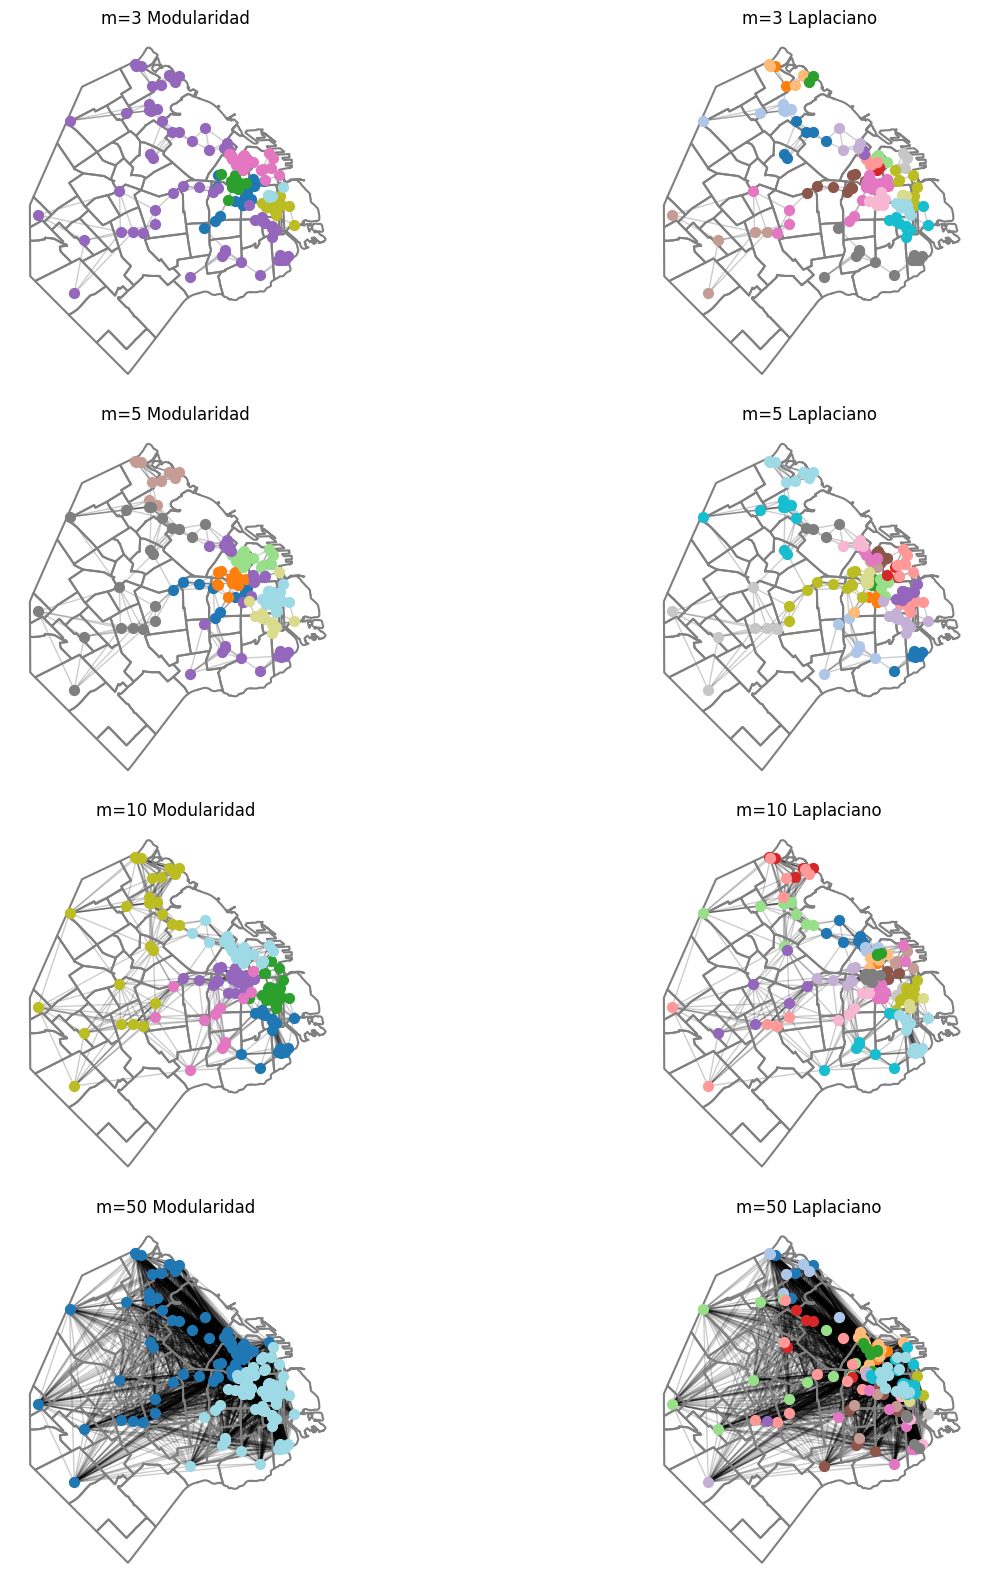

In [ ]:
D = construir_matriz_de_distancias(museos)

# Bucle para los casos m = 3, 5, 10, 50.
ms = [3, 5, 10, 50]
fig, axs = plt.subplots(len(ms), 2, figsize=(16, 4*len(ms)))

np.random.seed(25) # <----- Semilla

for idx, m in enumerate(ms):
    A = construye_adyacencia_simetrica(D, m)

    layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}
    G = nx.from_numpy_array(A)

    # Modularidad.
    R = calcula_R(A)
    comunidades_mod = modularidad_iterativo(R=R, nombres_s=list(range(A.shape[0])))
    graficar_comunidad(layout, G, comunidades_mod, idx, 0, axs, m, barrios, titulo="Modularidad")

    # Laplaciano.
    niveles = 5
    comunidades_lap = laplaciano_iterativo(A, niveles, list(range(A.shape[0])))
    graficar_comunidad(layout, G, comunidades_lap, idx, 1, axs, m, barrios, titulo="Laplaciano")

plt.tight_layout()
plt.show()

El método basado en modularidad busca maximizar la calidad de la partición deteniéndose automáticamente cuando ya no mejora la ganancia. Para valores bajos e intermedios de $m$ como $m$ = 10, produce divisiones coherentes y estables. Sin embargo, al aumentar $m$ en exceso como $m$ = 50, la red se densifica y la modularidad tiende a fusionar comunidades, perdiendo detalle y diferenciación significativa.

En contraste, el método del laplaciano iterativo realiza divisiones binarias en cada nivel. Su capacidad de resolver estructura interna es sensible a la cantidad de niveles elegidos: con pocos niveles, puede subsegmentar de forma adecuada; con demasiados, especialmente en redes densas con altos valores de $m$, genera sobresegmentación artificial sin respaldo topológico.

**Análisis de estabilidad frente a distintas semillas**:

El método de modularidad es estable, genera siempre la misma partición para un grafo dado, sin depender de la semilla. En cambio, el laplaciano iterativo muestra sensibilidad a la semilla, produciendo particiones algo distintas entre ejecuciones. Esto causa la necesidad de ejercer cautela al evaluar la robustez de sus resultados.

En síntesis, modularidad resulta más robusta ante la densificación de la red al adaptarse automáticamente, mientras que el método del laplaciano requiere un ajuste cuidadoso del número de niveles para evitar particiones excesivas o triviales según la conectividad impuesta por $m$.

## Punto 5: Síntesis final

En la primer parte del trabajo practico, los gráficos generados al variar los parámetros cantidad de conexiones (m) y probabilidad de salto (α) en el cálculo de Page Rank mostraron cómo la estructura espacial y la conectividad influyen de manera determinante en el ranking de los museos. Se observó que, para valores bajos de m, el ranking privilegiaba museos especializados o periféricos, con conexiones más limitadas. Sin embargo, al aumentar m, la red se densificaba y el ranking se concentraba en museos ubicados en zonas céntricas y con mayor interconectividad, desplazando a aquellos en regiones más alejadas. El efecto de α resultó más suave, pero igualmente significativo, con valores más bajos que acentuaban la dependencia en la topología local, mientras que valores altos distribuían más equitativamente la relevancia. Esta evidencia gráfica permitió concluir que la percepción de centralidad y relevancia en la red de museos es altamente sensible a la forma en que se modelan las conexiones geográficas y a los parámetros elegidos para el análisis.

En cambio en la segunda parte, pudimos observar patrones espaciales y topológicos claros en la red de museos de la Ciudad de Buenos Aires. Al analizar la distribución geográfica de las comunidades detectadas, se destaca que muchas de ellas se alinean con zonas céntricas o con alta densidad de museos, como el área histórica y los corredores culturales más consolidados. En los mapas, se evidencia cómo las conexiones más densas tienden a agrupar museos próximos físicamente, confirmando que la proximidad geográfica es un factor determinante en la formación de comunidades. Asimismo, los museos situados en barrios periféricos suelen aparecer en comunidades más pequeñas o incluso aisladas, lo cual resalta la desigual distribución de la oferta cultural en el territorio urbano.

En particular, los gráficos muestran que al aumentar la cantidad de conexiones permitidas con valores mayores de m, las comunidades detectadas tienden a volverse más grandes y difusas, perdiendo parte de su cohesión interna. Esto sugiere que la estructura comunitaria se remarcada en redes más "locales" con menor m, donde la cercanía física domina la conectividad, mientras que en redes densificadas el efecto de la distancia se diluye y se forman comunidades más extensas y heterogéneas. Además, se observó que el método de modularidad produce particiones más ajustadas a la forma de los barrios y corredores culturales, reflejando divisiones más intuitivas, mientras que el método del laplaciano genera cortes más equilibrados en tamaño pero a veces menos alineados con la distribución geográfica real. En conjunto, los resultados gráficos subrayan la importancia de considerar tanto la conectividad local como la geografía en el análisis de redes urbanas.

En conjunto, estos trabajos nos permitieron entender cómo distintas propiedades estructurales de una red (como la distancia entre nodos y la densidad de enlaces) pueden abordarse desde distintas perspectivas algebraicas para el análisis de la estructura de un grafo. Aprendimos a implementar y aplicar métodos iterativos para encontrar autovectores, y a darles un uso práctico en el análisis de grafos. Esta experiencia también nos enseñó sobre la importancia de investigar los distintos métodos para resolver un problema y contrastarlos entre sí para entender sus particularidades, sus ventajas y sus desventajas.

En términos de aplicaciones reales, estas metodologías podrían servir a usos más didacticos, como analizar el recorrido o pathing de un NPC en un videojuego para determinar los nodos en los que un encuentro con el mismo sea mas probable. En el ámbito industrial, empresas como YPF emplean centros de monitoreo en tiempo real para analizar datos de cada surtidor en estaciones de servicio. Conceptos como centralidad e identificación de comunidades pueden optimizar la logística de reposición, planificar mantenimientos preventivos con mayor precisión, o detectar patrones de consumo que sustenten una mejor toma de decisiones de venta.